# Study 777 — Black-Friday-Retail — for the quants 🔬

The full battery: one-sample *t* per window, a random-window placebo, a leave-one-out jackknife, the costed net leg, and a seeded synthetic positive control. Everything offline once cached; fingerprint `75498c2542dd`.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from black_friday_retail import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching XRT + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} Black Fridays resolved")


panel loaded; 20 of 20 Black Fridays resolved


## 1. One-sample *t* across independent Black-Friday years

Each Black Friday is one independent event, so the unit is a one-sample *t* of the per-year abnormal return — **not** a daily panel (which would fake precision).

In [2]:
for label, col in [('2wk run-up','pre_s'),('1mo run-up','pre_l'),('2wk fade','post_s'),('1mo fade','post_l')]:
    s = st.one_sample_t(inc[col].values)
    print(f'{label:<12s} n={s["n"]}  mean={s["mean"]*100:+.3f}%  sd={s["sd"]*100:.2f}%  t={s["t"]:+.3f}')

2wk run-up   n=20  mean=+1.333%  sd=3.76%  t=+1.585
1mo run-up   n=20  mean=+1.138%  sd=4.69%  t=+1.086
2wk fade     n=20  mean=+0.059%  sd=3.22%  t=+0.081
1mo fade     n=20  mean=-0.497%  sd=5.11%  t=-0.435


## 2. Random-window placebo — is the run-up inside the luck cloud?

For each event we redraw a random, non-Black-Friday 2-week window on XRT vs SPY and recompute the abnormal return; 20 seeds × 200 draws. If the observed mean sits in the tail of that null, it isn't ordinary tracking noise. Here it does — which is why the effect is *real-ish* even though the cross-year *t* (which pays the full year-to-year variance) is only ~1.6.

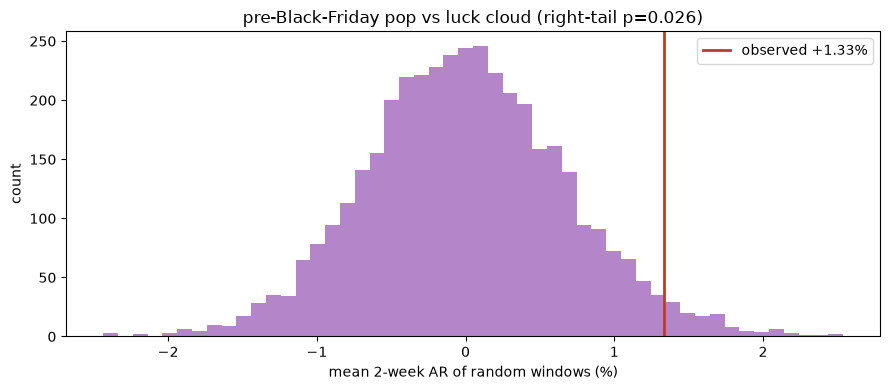

placebo: {'obs': 0.0133, 'placebo_mean': -0.0001, 'placebo_sd': 0.0067, 'p_value': 0.0262, 'n_draws': 4000}


In [3]:
pl = st.placebo_pvalue(ev, prices, 'pre_s', k=10, tail='right')
import numpy as np
xrt, spy = prices[dt.INSTRUMENT], prices[dt.BENCHMARK]
common = xrt.index.intersection(spy.index).sort_values()
rng = np.random.default_rng(999); draws = []
for _ in range(4000):
    vals = []
    for _e in range(int(inc.shape[0])):
        p = int(rng.integers(0, len(common)-11))
        vals.append(float(xrt.loc[common[p+10]]/xrt.loc[common[p]] - spy.loc[common[p+10]]/spy.loc[common[p]]))
    draws.append(np.mean(vals))
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(np.array(draws)*100, bins=50, color='#8e44ad', alpha=0.65)
ax.axvline(pl['obs']*100, color='#c0392b', lw=2, label=f"observed {pl['obs']*100:+.2f}%")
ax.set_xlabel('mean 2-week AR of random windows (%)'); ax.set_ylabel('count')
ax.set_title(f"pre-Black-Friday pop vs luck cloud (right-tail p={pl['p_value']:.3f})"); ax.legend()
plt.tight_layout(); plt.show()
print('placebo:', {k: round(v,4) if isinstance(v,float) else v for k,v in pl.items()})

## 3. Jackknife — is the run-up one great year, or broad?

In [4]:
x = inc['pre_s'].values
jk = [st.one_sample_t(np.delete(x, i))['t'] for i in range(len(x))]
print(f'full-sample t = {st.one_sample_t(x)["t"]:+.3f}')
print(f'jackknife t range [{min(jk):+.3f}, {max(jk):+.3f}] over {len(x)} leave-one-out draws')

full-sample t = +1.585
jackknife t range [+1.167, +2.145] over 20 leave-one-out draws


## 4. Tradability — net of costs

Calendar-known entry, so the signal window and the tradable window are the same (gross vs net). The run-up is a *long* in a liquid ETF, so it survives costs almost intact — but a +1.3%/yr window with *t* ≈ 1.5 is one positive cut inside a four-window search, and its 'sell the news' partner doesn't exist.

In [5]:
ev10 = st.build_event_table(prices, cost_bps=10.0); inc10 = ev10[ev10['included']]
for base, label in [('pre_s','2wk run-up'),('post_s','2wk fade')]:
    g = st.one_sample_t(inc[base].values); n5 = st.one_sample_t(inc[base+'_net'].values); n10 = st.one_sample_t(inc10[base+'_net'].values)
    print(f'{label:<12s} gross {g["mean"]*100:+.3f}% (t={g["t"]:+.2f})  net@5 {n5["mean"]*100:+.3f}% (t={n5["t"]:+.2f})  net@10 {n10["mean"]*100:+.3f}% (t={n10["t"]:+.2f})')

2wk run-up   gross +1.333% (t=+1.59)  net@5 +1.233% (t=+1.47)  net@10 +1.133% (t=+1.35)
2wk fade     gross +0.059% (t=+0.08)  net@5 -0.041% (t=-0.06)  net@10 -0.141% (t=-0.20)


## 5. Synthetic positive control — the detector works, and the null is noisy

The one-sample-*t* detector must stay quiet on a planted-null world and recover a planted pre-Black-Friday bump. Note the honest small-sample false-positive rate at n = 20 with a 10-day AR: |*t*| ≥ 2 fires on ~3/20 null seeds — a reason not to over-read the observed +1.59.

null: mean t=-0.59 sd=1.49  |t|>=2 in 3/20 seeds
planted +1%: mean AR +2.474%  t=+3.72
planted +2%: mean AR +3.474%  t=+5.23


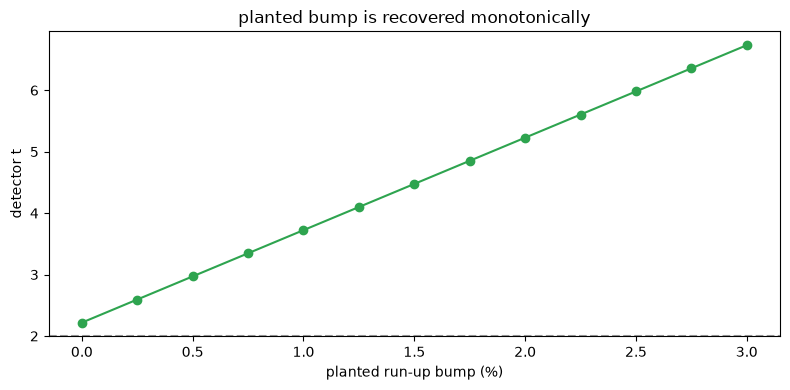

In [6]:
null_ts = np.array([st.synthetic_detect(bump=0.0, seed=783+s, k=10)['t'] for s in range(20)])
print(f'null: mean t={null_ts.mean():+.2f} sd={null_ts.std(ddof=1):.2f}  |t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds')
for b in (0.01, 0.02):
    r = st.synthetic_detect(bump=b, seed=783, k=10)
    print(f'planted +{b*100:.0f}%: mean AR {r["mean"]*100:+.3f}%  t={r["t"]:+.2f}')
bumps = np.linspace(0, 0.03, 13)
ts = [st.synthetic_detect(bump=b, seed=783, k=10)['t'] for b in bumps]
fig, ax = plt.subplots(figsize=(8,4)); ax.plot(bumps*100, ts, 'o-', color='#2ea44f')
ax.axhline(2, color='0.6', ls='--'); ax.set_xlabel('planted run-up bump (%)'); ax.set_ylabel('detector t')
ax.set_title('planted bump is recovered monotonically'); plt.tight_layout(); plt.show()

## Verdict

**Signal: Weak.** The run-up points the right way (2-week run-up +1.33%, *t* = +1.59, placebo right-tail ≈ 0.026, jackknife stays positive) — a genuine, directionally-correct whiff, more than most calendar folklore delivers — but the cross-year *t* is short of significance, it weakens at a 1-month lookback, the fade is a clean zero, and the null fires |*t*| ≥ 2 on 3/20 seeds at this n. **Tradability: Mirage.** Net +1.2%/yr with *t* ≈ 1.5 is one positive cut inside a four-window search with no partner reversal — liquid and long, but no reliable edge to size.